## Lab 2: Differential Diagnosis and Conditional Expectation

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
import graphviz

# Load data
df = pd.read_csv('./data/ed_visits_probability_lab_train.csv')
test = pd.read_csv('./data/ed_visits_probability_lab_test.csv')


A differential diagnosis is when a health care provider uses the availability of information about different symptoms to try to narrow down the set of possible health problems a patient might be experiencing, before recommending further testing or treatment.

We are not doctors, but we do have the National Hospital Ambulatory Medical Care Survey. The version we will use is **heavily** cleaned and simplified for our lab, please do not use it for research or any other purposes.

Here are the key pieces, in `./data/ed_visits_probability_lab_train.csv` and `./data/ed_visits_probability_lab_test.csv` files both contain:
- The patient's International Classification of Diseases (ICD) code has been simplified in the `disease_group` variable, with 18 categories like `cardiovascular` or `neurological`.
- There are binary symptoms: 'abdominal_pain', 'cough',
       'vomiting', 'fever', 'nausea', 'chest_pain', 'shortness_of_breath',
       'headache', 'accident', 'dizziness', 'back_pain', 'anxiety',
       'skin_rash'
- There are some other variables that likely have predictive value: `sex`, `arrival_by_ambulance`, and age group bins for under 20, 20-40, 40-60, 60-70, and over 70.

Note that you might have a skin rash because you have seborrheic dermatitis, and the underlying condition is actually Parkinson's Disease, which is neurological in nature. Likewise, a person who arrives in an ambulance with chest pain might be having a heart attack, but a walk-in with slight pain might be having an aortic dissection. Just because you have one kind of symptom that is representative of one class of diseases doesn't rule out complex or unexpected causes.

We are going to use the Decision Tree Classifier to learn more about conditional expectation. **This is not a lab about machine learning.** The decision tree classifier splits the sample according to questions about symptoms as it moves through the tree, and computes a probability mass function at each step that represents the proportions of the remaining part of the population with each of the disease codes.

## Step 1:

Run the code below, installing `scikit-learn` and `graphviz` as necessary.

In [6]:
# Symptom variables
symptoms = [
    'abdominal_pain', 'cough', 'vomiting', 'fever', 'nausea',
    'chest_pain', 'shortness_of_breath', 'headache', 'accident',
    'dizziness', 'back_pain', 'anxiety', 'skin_rash',
]

# Patient-context variables
patient_vars = [
    'arrival_by_ambulance', 'sex',
    'age_u20', 'age_20_40', 'age_40_60', 'age_60_70', 'age_o70',
]

x_vars = symptoms + patient_vars

# Explanatory-variable matrices
X = df[x_vars].to_numpy()
X_test = test[x_vars].to_numpy()

print('Disease groups:')
print(df['disease_group'].value_counts())


Disease groups:
disease_group
injury_trauma               17711
general_constitutional       8048
other                        5924
ear_nose_throat_eye          4800
gastrointestinal             3911
genitourinary_renal          3796
respiratory                  3688
psychiatric_behavioral       3637
musculoskeletal              3430
infectious_disease           2988
cardiovascular               2320
endocrine_metabolic          2012
dermatologic                 1811
injury_adverse_care          1511
neurological                 1270
pregnancy_related            1237
injury_poisoning              779
hepatobiliary_pancreatic      618
Name: count, dtype: int64


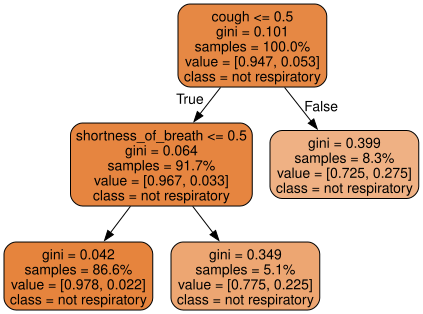

In [26]:
# Set outcome variable:
disease = 'respiratory'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease] #Left number is P(not respiratory) and right number is P(respiratory)

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-3, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

The above object is a **decision tree classifier**: It predicts class labels on the basis of covariates. At each **node** in the graph, there is a condition, like `cough<=.5`. Depending on how the case evaluates, we move left (`True`) or right (`False`) down the tree along the **edges**. At each node, we also see the probability mass function, conditional on the current information set. At the bottom of the tree are **terminal leaves** with hard classification predictions and the final proportions.

The tree classifier pictured in the previous code chunk provides the probability mass function over the labels "not respiratory" and "respiratory". It starts as 95% of patients not having a respiratory problem, and 5% having a respiratory problem. The first differential diagnosis question is, "Does the patient have a cough?" If they do have a cough, we update our estimate to .73/.27, and if not, we update to .97/.03. If you have a cough, shortness of breath, you reach the highest estimate, .59/.41.

This is exactly what conditional probability and conditional expectation are: We update our beliefs based on evidence, and that reshapes our posterior estimates of the probabilities of different outcomes.

The probabilities displayed by the tree are fitted conditional estimates: they are the training-data class proportions among patients reaching each node. They are useful for this lab, but they are not calibrated clinical risk estimates.

<div class="alert alert-block alert-warning">

Which combinations of symptoms make a respiratory disease the most likely explanation? The least likely?

</div>

1. Having a cough and then shortness of breath gives a P(respiratory) = .415. The least likely is no cough, no shortness of breath, and no fever which gives P(respiratory) = .018.

<div class="alert alert-block alert-warning">
Which variables does the tree exploit? 
</div>

2. Cough, shortness of breath, fever, chest pain, dizziness, and arrival by ambulance.

<div class="alert alert-block alert-warning">
Clearly explain how the tree is a representation of conditional updating, where we condition on reported symptoms to provide new probability estimates based on new information.
</div>

3. The first node checks if someone simply has a cough or not which is just P(respiratory | cough) vs P(not respiratory | cough). From that we go to check shortness of breath. This leads to the next nodes being P(respiratory | cough, shortness of breath) and P(not respiratory | cough, shortness of breath). This continues until we end at the bottom of the tree. We get updated probabilities of respiratory or not with each new node / variable that we include. 

<div class="alert alert-block alert-warning">
Run the code again, but try values of 1e-3=0.001, 1e-5=0.00001 and 1e-7=0.0000001 for `min_impurity_decrease` to allow it to explore more complex explanations of the data. For each value of the `min_impurity_decrease` hyperparameter, find the terminal leaves with the lowest and highest probabilities of respiratory disease. How do these values vary with the complexity of the tree?
</div>

4. 1-e3 is much shallower and only ends up looking at respiratory or not given a cough and subsequently shortness of breath on the cough side.
5. 1-e5 goes much further in depth to a point where some of the comparisons are likely not very helpful. Accident being included and have a 0% probability of being respiratory shows how this can rule out options entirely. In addition the maximum probabilities do go up so we can increase certainty. However the addition of more nodes causes more noise and makes it much more difficult to read, in addition some of the outcomes only have a few patients that experienced that specific combination make it difficult to gather useful insight from. 
6. 1-e7 takes that but makes it much worse and ultimately hard to understand. There are so many nodes that is is difficult to visualize and properly understand. This expands upon what the failures of 1-e5 and made it far worse.



<div class="alert alert-block alert-warning">

Repeat the previous step with `disease = 'neurological'` and `min_impurity_decrease = 1e-3`. What variables are used in the tree? Which variables raise or lower the predicted probability of a neurological diagnosis?

</div>

7. There only is one node and no variables associated with it. Because of this, there is no way to kno wwhich variables raise or lower the predicted probability of a neurological disease.

## Step 2:

In step 1, we tried to predict whether a patient has a single condition or not. Now, we want to predict the entire probability mass function.

The code block sets `y = df['disease_group']` and `outcome = df['disease_group'].unique()`, and runs a similar analysis. The result is now a fitted differential diagnosis: an estimated probability mass function over the labels and a hard classification label. For readability, we set `max_depth = 3`.

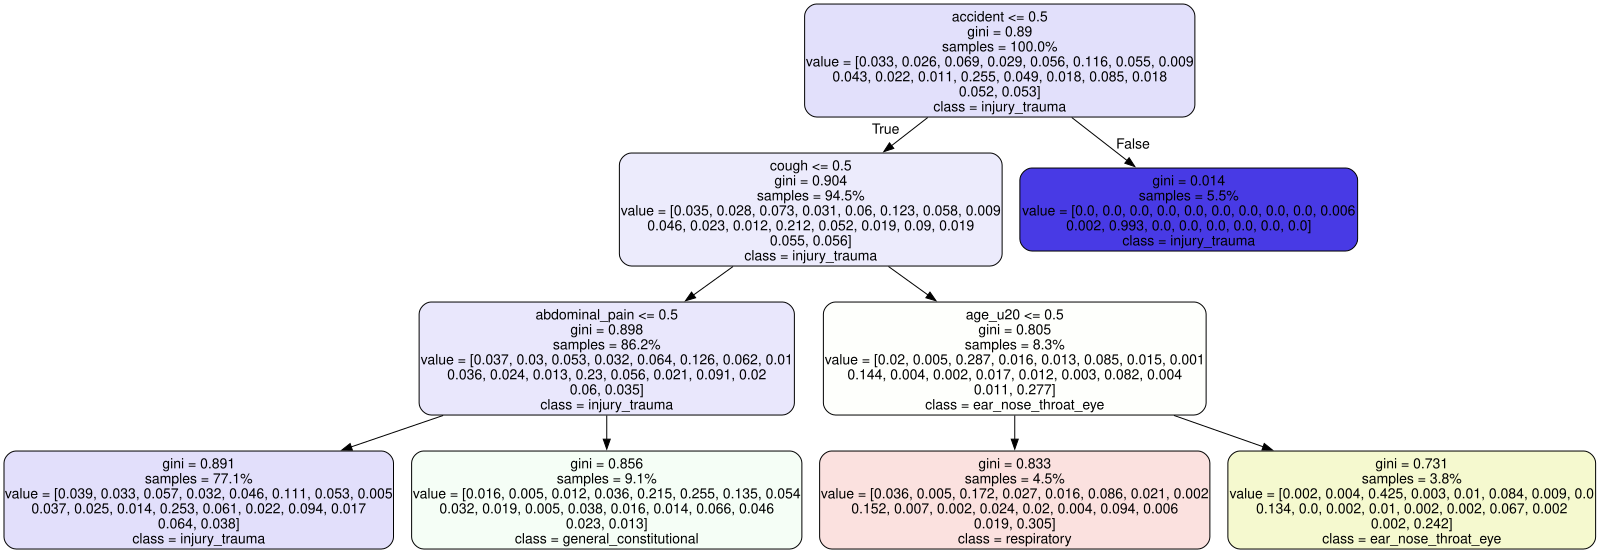

In [20]:
# Set outcome variable:
y = df['disease_group']
## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 3, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-4, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)


# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=model.classes_,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

<div class="alert alert-block alert-warning">
Which diseases are predicted as hard classifications in the tree? For those labels, does the probability of that disease exceed even a moderate value like .3 or .5, or not? Why might this be a concern?
</div>

1. injury trauma, respiratory, general constitutional, and ear nose throat and eye. 
    1. If you come in with an accident, the probability it is injury trauma is .993 > .5 > .3
    2. If you dont have an accident, and dont have abdominal pain then your probability of injury trauma is .254 < .3
    3. Ear, nose, throat and eye given you didnt have an accident, do have a cough, and are under 20 has a probability of 0.425. .5 > .425 > .3
    4. Respiratory given you didnt have an accident, do have a cough, and are over 20 has a probability of .305. .5 > .305 > .3
    5. General constitution does not have any above .3. The highest is .255 which is if you didn't have an accident, and do have abdominal pain.

<div class="alert alert-block alert-warning">
Which labels have the highest or lowest probabilities for the predicted disease class labels? 
</div>

2. Injury Trauma for both

<div class="alert alert-block alert-warning">
Which conditions and values are used in the tree?
</div>

3. Conditions: Accident, cough, abdominal paid, and under 20. All of these are compared at <= .5 which just determines if it is a 1 or a 0.

<div class="alert alert-block alert-warning">
Even if the probabilities for each terminal leaf remain fairly small in absolute terms, why can a differential diagnosis tool like this still be useful for doctors?
</div>

4. Some probabilities can look weak alone, but when we look at them together, we can see how much higher the probability is than the probability on the frist node. Injury trauma goes up from .255 to .993 once we know there was an accident. By conditioning on other symptoms doctors can help narrow down from many different possibilities that are all somewhat unlikely, to a few possibilities that are far more likely than the others. 



In [25]:
t = model.tree_
leaves = [i for i in range(t.node_count) if t.children_left[i] == -1]
pd.DataFrame({
    'n':     t.n_node_samples[leaves],
    'class': model.classes_[[t.value[i][0].argmax() for i in leaves]],
    'p_max': [t.value[i][0].max().round(3) for i in leaves],
}).sort_values('p_max', ascending=False)

,n,class,p_max
4,3839,injury_trauma,0.993
3,2612,ear_nose_throat_eye,0.425
2,3131,respiratory,0.305
1,6314,general_constitutional,0.255
0,53595,injury_trauma,0.253
